In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from astropy.io import fits
from matplotlib import colors
import matplotlib.patches as patches
from matplotlib.colors import LogNorm
from matplotlib.colors import FuncNorm
from matplotlib.patches import Ellipse
from matplotlib.patches import Circle
from ellipse import LsqEllipse

In [2]:
import pickle

wray_qphi = pickle.load(open('wray_qphi', 'rb'))
wray_qphi_d = pickle.load(open('wray_qphi_d', 'rb'))
wray_qphi_polar_extended = pickle.load(open('wray_qphi_polar_extended', 'rb'))

Let us now draw a **quadrilateral**, inside which we shall fit the spiral arm:

In [3]:
def overplot_quadrilateral(vertices, color='red', linewidth=2, alpha=1.0, closed=True):
    
    ax = plt.gca()  # Get current axes
    
    # Extract coordinates
    x_coords = [v[0] for v in vertices]
    y_coords = [v[1] for v in vertices]
    
    # Close the shape if needed
    if closed:
        x_coords.append(vertices[0][0])
        y_coords.append(vertices[0][1])
    
    # Overplot the quadrilateral
    ax.plot(x_coords, y_coords, color=color, linewidth=linewidth, alpha=alpha)

Let us begin with the fit with an **archimedean** spiral arm (we remember again that we are doing the fit **inside the quadrilateral**):

In [4]:
def log_spiral( x, a, b, phi0, r0=0):
    '''x is the azimuthal position in pixel. All angle inputs in DEG'''
    phi = np.deg2rad( x - phi0 + -90 )     # from coord to actual azim angle on disk plane (-90 is the polshift)
    r = a * np.exp( b * phi) + r0
    return r

def arch_spiral( x, a, b, phi0):
    phi = np.deg2rad( x - phi0 + -90 )     # from coord to actual azim angle on disk plane (-90 is the polshift)
    r = a + b * phi
    return r


def plot_spiral( data, sp_type, a, b, r0=0, phi0=0, polshift=-90, data_bound=True):
    
    # sign = +1 if (clockwise == True) else -1    # direction of spiral increase
    x = np.arange( data.shape[1] )          # the x coordinates on the data
    phi = np.deg2rad( x - phi0 + polshift )              # the az angles corresponding to each x, centred on phi0, accounting for polshift 
    if sp_type == 'log':
        r = a * np.exp( b * phi) + r0
    else: # archimedean
        r = a + b * phi
    if data_bound:
        bound = ( r > 1 ) & ( r < data.shape[0] - 1 )
        r = r[bound]
        x = x[bound]
    return x, r


def au_to_pix( au, scale, parallax=2.85):
    return au * parallax / scale

def pix_to_au( pix, scale, parallax=2.85):
    return pix * scale / parallax

def au_deg_ticks( ax_obj, shift, pixscale):
    '''Format the ticks to put au on the Y and degrees on the X, for horizontal polar images.'''
    def au_format( value, pos):
        """The two arguments are the value and tick position"""
        x_au = pix_to_au( value, scale=pixscale)
        return f'{x_au :3.0f}'

    def deg_format( value, pos):
        x_deg = value + shift
        return f'{x_deg :.0f}'

    ax_obj.yaxis.set_major_locator( mpl.ticker.MultipleLocator( au_to_pix( 100, pixscale) ))
    ax_obj.yaxis.set_minor_locator( mpl.ticker.MultipleLocator( au_to_pix( 50, pixscale) ))
    ax_obj.yaxis.set_major_formatter( au_format )
    ax_obj.xaxis.set_major_locator( mpl.ticker.MultipleLocator( 90 ))
    ax_obj.xaxis.set_minor_locator( mpl.ticker.MultipleLocator( 20 ))
    ax_obj.xaxis.set_major_formatter( deg_format )   
    return



def arm_bounds( arm_ID, folder='./Datapoints4/' ):
    '''
    Find the endpoints of the spiral arm based on the sampled coordinates points of given arm.
    '''
    filelist = sorted( glob.glob( f'{folder}*{arm_ID}*.dat', recursive=True) )
    extrema = np.array([])
    for file in filelist: 
        data = np.loadtxt( file )
        points = data[1:]         # remove first line since it was a zoom click
        for i in [0,1]:     # cycle on x and y
            extrema = np.append(  extrema, [points[:,i].min(), points[:,i].max() ] )    # xmin, xmax, ymin, ymax for each file : one line
    extr = extrema.reshape(-1,4)
    xmin, ymin = extr[:,[0,2]].min( axis=0)
    xmax, ymax = extr[:,[1,3]].max( axis=0)
    return (xmin, xmax), (ymin, ymax)


def pitch_angle( sp_type, b , r_ev=40, absval=True):
    '''Returns pitch angle for given spiral tipe. r_ev is the evalutation radius to compute the archimedean pitch angle'''
    if sp_type == 'log':
        p =  np.rad2deg( np.arctan( b ) )
    else:   # arch
        p = np.rad2deg( np.arctan(b / r_ev) )    # r and b must have same units
    if absval:
        p = abs(p)
    return p


def pitch_error( sp_type, b_best, stds, r_ev):
    '''Provide an error based on the one sigma distance b values.'''
    b_lo = b_best - stds[1] #* ([-1, +1])
    b_hi = b_best + stds[1]
    p_lo = pitch_angle( sp_type=sp_type, b=b_lo, r_ev=r_ev )
    p_hi = pitch_angle( sp_type=sp_type, b=b_hi, r_ev=r_ev )
    err = ( p_hi - p_lo) / 2
    return abs(err)


def fit_spiral( data, sp_type, prints=True, figure=True, arm_name='', folder='./'):
    '''Fit the datapoints to the chosen spiral type equation. Prints the resulting fit parameters, the pitch angle and the chisquare.'''
    if sp_type == 'log':
        spiral_func = log_spiral
        param_bounds = ( [1, -np.inf, -360, 0], [250, np.inf, 720, 0.1] )        # limits on spiral parameters a, b, phi0, (r0 constrained)
        init_guess = ([10, -0.8, 180, 0])
    else:
        spiral_func = arch_spiral
        param_bounds = ( [1, -np.inf, 0], [100, np.inf, 200] )           # limits on spiral parameters a, b, phi0
        init_guess = ([35, -3.6, 100])

    try: errors = data[:,2]
    except: errors = None
    IN_popt, IN_pcov = curve_fit( spiral_func, xdata= data[:,0], ydata= data[:,1], sigma=errors, p0=init_guess, bounds=param_bounds, absolute_sigma=False )
    fit_stds = np.sqrt(np.diag( IN_pcov ))          # from scipy doc
    y_pred = spiral_func( data[:,0], *IN_popt)       # fit predictions
    res = y_pred - data[:,1]                        # residues
    chisq = sum( res**2 / y_pred) / ( len(data) - len(init_guess) )        # reduced chi-square
    arm_ID = arm_name.replace( 'spi_', '').replace( '_q', '').replace( '_a', '')      # clean names
    eval_rad = 13
    #eval_rad = arm_bounds( arm_ID=arm_ID, folder=folder )[1][0]            # r_ev = ymin for each arm
    pitch_ang = pitch_angle( sp_type=sp_type, b= IN_popt[1], absval=True, r_ev= eval_rad )
    pitch_std = pitch_error( sp_type=sp_type, b_best=IN_popt[1], stds=fit_stds, r_ev= eval_rad)
    if prints:
        print( 'fit: a= %.3f [pix], b= %.3f [1/rad], phi0= %.2f [deg]' % tuple(IN_popt[0:3]) )
        if sp_type == 'log': print( f'r0 = {IN_popt[-1] :.2f} [pix]')
        print( 'Fit 1 sigma errors:', fit_stds )     # errors on a and r0 are enormous
        print( f'reduced chi-square of fit: \t {chisq :.3f}' )
        print( f'abs pitch angle: [deg] \t {pitch_ang :.2f} +/- {pitch_std :.2f} \t\t eval radius [pix]: {eval_rad}' )
    if figure:
        xsort = np.argsort( data[:,0] )     # to draw the lines monotonically
        fig, ax = plt.subplots( figsize=(7,5), constrained_layout=True)
        # au_deg_ticks( ax, -90, ird_scale)        # this only changes the label format, not the actual xy values of rows n cols
        # cnorm = mpl.colors.SymLogNorm( vmin=dataset.min(), vmax=dataset.max(), linthresh=3e-05, linscale=0.8, base=np.e)
        #ax.imshow( dataset, origin='lower', cmap='inferno', norm=cnorm )
        ax.scatter(data[:,0], data[:,1], c='tab:green', alpha=0.65)
        ax.plot( data[:,0][xsort], y_pred[xsort], c='tab:blue')
        ax.annotate( text=f'$\chi^2$ = {chisq :.2f}', xy=(0.6, 0.8), xycoords='axes fraction', color='k')
        ax.set( xlabel='$\phi$  (°)', ylabel='$r$  (pix)', title=f'{sp_type} fit: {arm_name}' )
        plt.show()
    return [ *IN_popt, pitch_ang, chisq, *fit_stds, pitch_std]

def overlay_ellipse(center, width, height, angle=0, alpha=0.5, edgecolor='red', facecolor='none', linewidth=2):
    ax = plt.gca()  # Get current axes
    ellipse = Ellipse(
        xy=center,
        width=width,
        height=height,
        angle=angle,
        edgecolor=edgecolor,
        facecolor=facecolor,
        alpha=alpha,
        linewidth=linewidth
    )
    ax.add_patch(ellipse)
    return ax

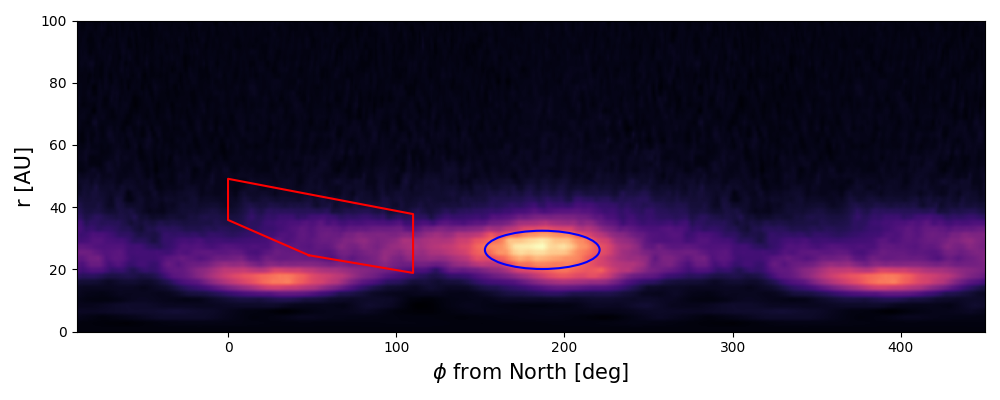

In [5]:
AU_scale = 1.89 # AU/pixel (at a distance of 151 pc)
p_extent = [-90, 450, 0, wray_qphi_polar_extended.shape[0] * AU_scale]

vertices_corr = [(138, 13), (90, 19), (90, 26), (200, 20), (200, 10)]
vertices_corr_d = [(138-90, 13*AU_scale), (90-90, 19*AU_scale), (90-90, 26*AU_scale), (200-90, 20*AU_scale), (200-90, 10*AU_scale)]

blob_center_phi = 186.8
blob_center_r = 26.3
blob_width_phi = 68.2
blob_width_r = 12.3

blob = Ellipse(xy=(blob_center_phi, blob_center_r),  # center coordinates
                  width=blob_width_phi,                # width (phi direction)
                  height=blob_width_r,                 # height (r direction)
                  angle=0,                             # rotation angle in degrees
                  edgecolor='blue',
                  facecolor='none',
                  linewidth=1.5,
                  label='Blob')

fig, ax = plt.subplots(figsize=(10,4))

ax.imshow(wray_qphi_polar_extended, origin='lower', cmap='magma', aspect='auto', extent=p_extent)
overplot_quadrilateral(vertices=vertices_corr_d, color='red', linewidth=1.5, alpha=1.0, closed=True)
ax.add_patch(blob)
ax.set_ylim(0, 100)
ax.set_xlabel('$\phi$ from North [deg]', fontsize=15)
ax.set_ylabel('r [AU]', fontsize=15)

plt.tight_layout()
plt.show()

In [6]:
import cv2

mask = np.zeros(wray_qphi_polar_extended.shape[:2], dtype=np.uint8)
print (mask, np.shape(mask))

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] (512, 540)


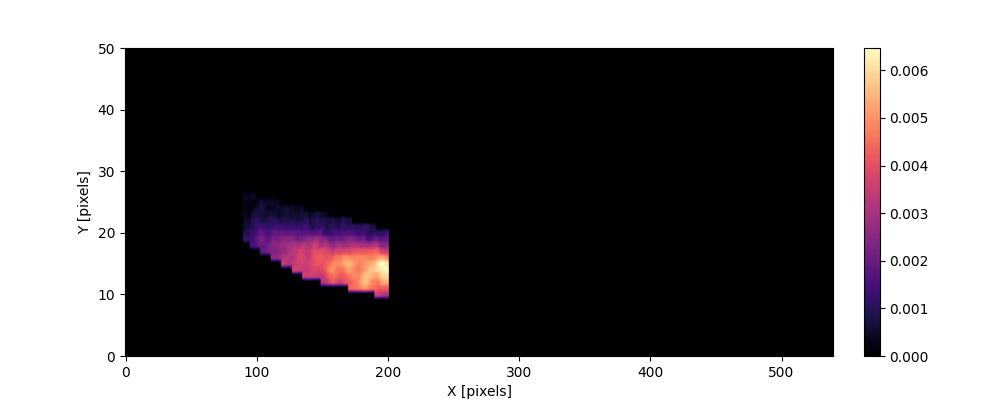

In [7]:
cv2.fillPoly(mask, [np.array(vertices_corr)], 255)

# Apply mask
result = cv2.bitwise_and(wray_qphi_polar_extended, wray_qphi_polar_extended, mask=mask)

plt.figure(figsize=(10,4))
plt.imshow(result, origin='lower', cmap='magma', aspect='auto')
plt.colorbar(fraction=0.046, pad=0.04)
plt.ylim(0, 50)
plt.xlabel('X [pixels]')
plt.ylabel('Y [pixels]')
plt.show()

In [8]:
cont_value = 1e-3
rs, phis = np.nonzero( result > cont_value)

arm_coords = np.array( list( zip( phis, rs)) )
print (arm_coords, np.shape(arm_coords))

[[190  10]
 [191  10]
 [192  10]
 ...
 [145  22]
 [146  22]
 [166  22]] (898, 2)


fit: a= 11.657 [pix], b= -0.153 [1/rad], phi0= 194.52 [deg]
r0 = 0.10 [pix]
Fit 1 sigma errors: [5.13513186e+06 2.80755837e-01 1.65226477e+08 3.06989359e+01]
reduced chi-square of fit: 	 0.437
abs pitch angle: [deg] 	 8.69 +/- 8.07 		 eval radius [pix]: 13


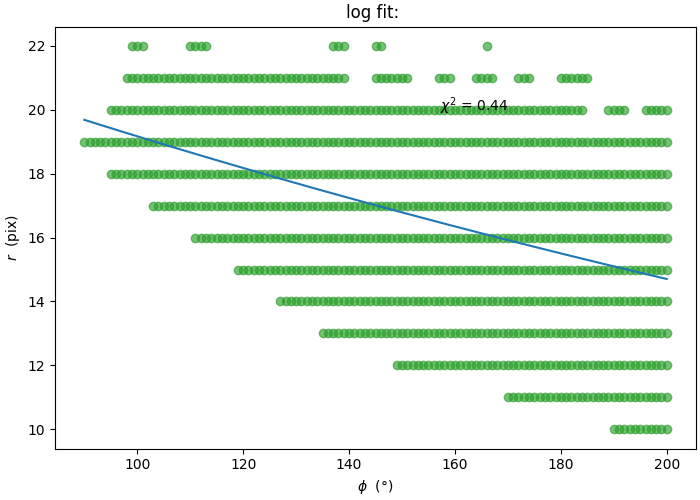

fit: a= 14.813 [pix], b= -2.534 [1/rad], phi0= 105.74 [deg]
Fit 1 sigma errors: [5.04584705e+06 1.75363831e-01 1.14097113e+08]
reduced chi-square of fit: 	 0.437
abs pitch angle: [deg] 	 11.03 +/- 0.74 		 eval radius [pix]: 13


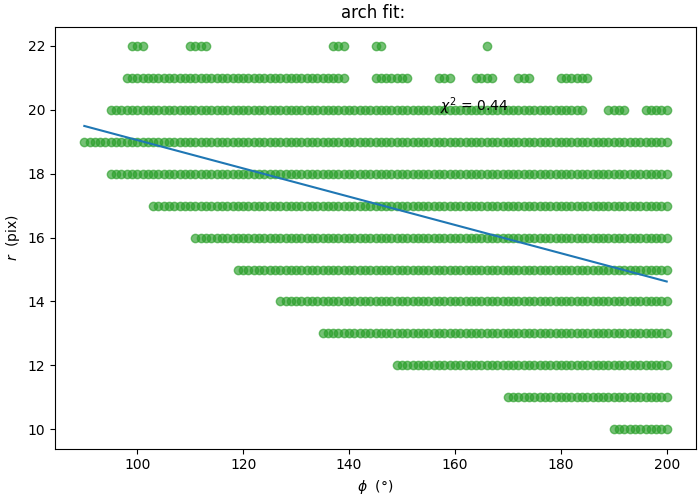

11.657307064267197 -0.15275537027383923 194.5207810860849
14.812990253369158 -2.533856735682958 105.7428442245841


In [9]:
from scipy.optimize import curve_fit
import glob

np.savetxt( 'arm_q.dat', arm_coords)

armdata = np.loadtxt( 'arm_q.dat')
log_spiral_data = fit_spiral( armdata, 'log')

arch_spiral_data = fit_spiral( armdata, 'arch')

a_log, b_log, phi0_log = log_spiral_data[0:3]
a_arch, b_arch, phi0_arch = arch_spiral_data[0:3]
print (a_log, b_log, phi0_log)
print (a_arch, b_arch, phi0_arch)

And now we **plot** both the logarithmic and archimedean spiral fit:

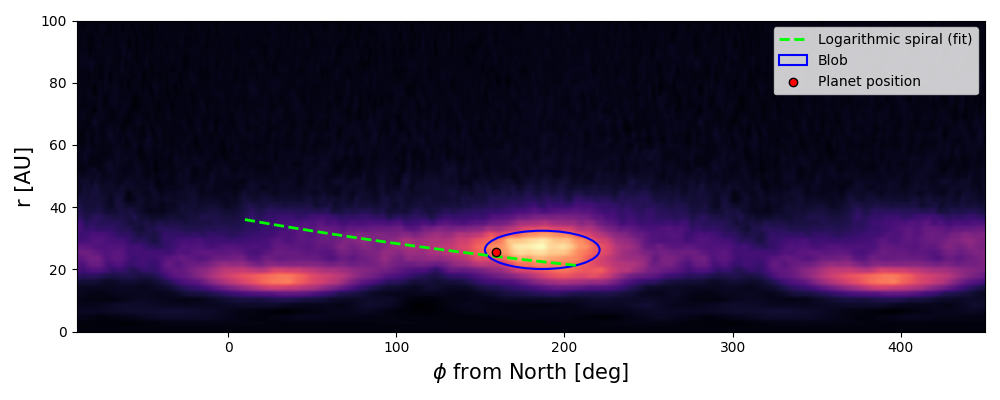

In [10]:
def arch_spiral(phi, a, b, phi0):
    x = np.deg2rad(phi - phi0)
    y = a + b * x
    r = AU_scale * y  # rescaling y (AU)
    return phi, r

def log_spiral(phi, a, b, phi0, r0=0):
    x = np.deg2rad(phi - phi0)     # from coord to actual azim angle on disk plane (-90 is the polshift)
    y = a * np.exp(b * x) + r0
    r = AU_scale * y  # rescaling y (AU)
    return phi, r

phi = np.arange(10, 210, 1)

phi_log, r_log = log_spiral(phi, a_log, b_log, phi0_log)
phi_arch, r_arch = arch_spiral(phi, a_arch, b_arch, phi0_arch)

angle_p = 159.3
radius_p = 25.7

blob = Ellipse(xy=(blob_center_phi, blob_center_r),  # center coordinates
                  width=blob_width_phi,                # width (phi direction)
                  height=blob_width_r,                 # height (r direction)
                  angle=0,                             # rotation angle in degrees
                  edgecolor='blue',
                  facecolor='none',
                  linewidth=1.5,
                  label='Blob')

fig, ax = plt.subplots(figsize=(10, 4))

#im = ax.imshow(wray_qphi_polar_extended, origin='lower', cmap='magma', extent=p_extent, aspect='auto', norm=LogNorm(vmin=10**-8, vmax=2.5e-7))
im = ax.imshow(wray_qphi_polar_extended, origin='lower', cmap='magma', extent=p_extent, aspect='auto')
#ax.plot(phi_arch, r_arch, color='white', linewidth=2, linestyle='--', label='Archimedean spiral (fit)')
ax.plot(phi_log, r_log, color='lime', linewidth=2, linestyle='--', label='Logarithmic spiral (fit)')
ax.add_patch(blob)
ax.scatter(angle_p, radius_p, c='red', edgecolors='black', label='Planet position', zorder=10)
ax.legend()
ax.set_ylim(0, 100)
ax.set_xlabel('$\phi$ from North [deg]', fontsize=15)
ax.set_ylabel('r [AU]', fontsize=15)

plt.tight_layout()
plt.show()

So, this is our result. by fact, the archimedean fit and the spiral fit almost **overlap**. The spiral goes from 8 to 108 deg from North. Actually, we do not know where does the spiral begin. My hypothesis is that at 108 deg, the spiral is covered by the inner part of the ring (I assume that the region between 108 and 160 deg is the inner part of the ring because it is horizontal in the (r, $\phi$) plot); therefore it **does not end there**, but could continue, even inside the coronargaph. We could estimate the planet's mass and position, according also to the position of the blob and the pitch angle: the planet should be located **between the spiral and the blob**, in the ellipse position (remember to cite the article with the kink velocity that is modified!).

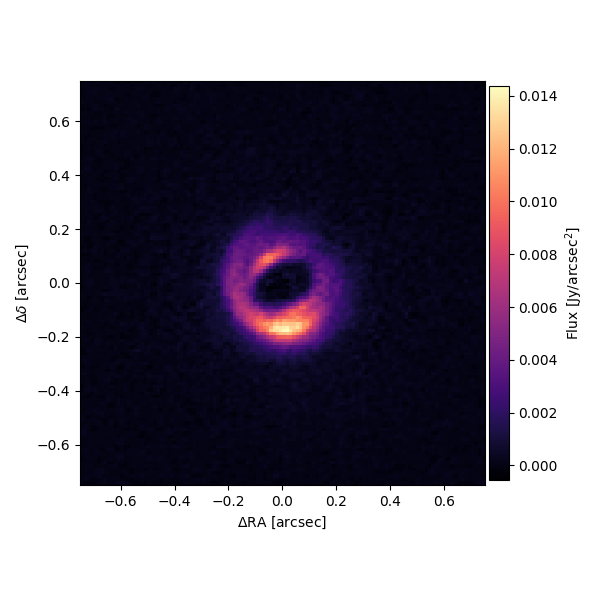

In [11]:
# Let us see the deprojeccted disk image:
# Define circle parameters
scale = 12.251/1000. # number of arcsec/px

extent = [
    -wray_qphi.shape[1] * scale / 2,  # Left = -width/2 (as)
    wray_qphi.shape[1] * scale / 2,   # Right = +width/2 (as)
    -wray_qphi.shape[0] * scale / 2,  # Bottom = -height/2 (as)
    wray_qphi.shape[0] * scale / 2,   # Top = +height/2 (as)
]

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(wray_qphi_d, origin='lower', cmap='magma', extent=extent)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01, label=r"Flux [Jy/arcsec$^2$]")
ax.set_xlabel(r'$\Delta$RA [arcsec]')
ax.set_ylabel(r'$\Delta\delta$ [arcsec]')
ax.set_xlim(-0.75, 0.75)
ax.set_ylim(-0.75, 0.75)

plt.tight_layout()
plt.show()

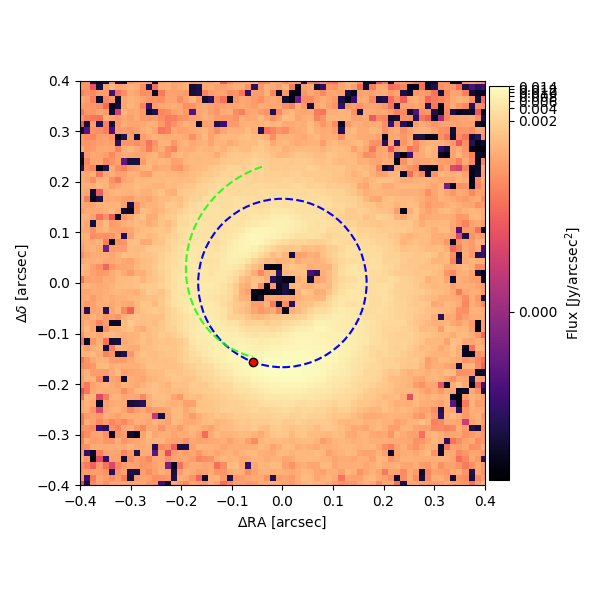

In [12]:
phi = np.arange(10, 158.5, 1)

phi_log, r_log = log_spiral(phi, a_log, b_log, phi0_log)

# Convert polar to Cartesian coordinates (add 90 deg to phi_log because we start from North)
x = r_log / AU_scale * 0.012251 * np.cos(np.deg2rad(phi_log + 90))
y = r_log / AU_scale * 0.012251 * np.sin(np.deg2rad(phi_log + 90))

radius_p_arcsec = radius_p / AU_scale * 0.012251
x_planet = radius_p_arcsec * np.cos(np.deg2rad(angle_p + 90))
y_planet = radius_p_arcsec * np.sin(np.deg2rad(angle_p + 90))

# Define the asinh transformation functions
def forward(x, scale=8e-8):
    """Transform data to asinh space for colormap"""
    return np.arcsinh(x / scale)

def inverse(x, scale=8e-8):
    """Transform back from asinh space"""
    return scale * np.sinh(x)

# Create the normalization object
# Adjust 'scale' parameter to control the stretch strength
# (smaller values show more faint features)
norm = FuncNorm((forward, inverse), 
                vmin=np.nanmin(wray_qphi_d),  # Use nanmin if there are NaN values
                vmax=np.nanmax(wray_qphi_d))  # Use nanmax if there are NaN values

# Plot the spiral arm
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(wray_qphi_d, origin='lower', cmap='magma', extent=extent, norm=norm)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01, label=r"Flux [Jy/arcsec$^2$]")
ax.plot(x, y, 'lime', linestyle='--', linewidth=1.5, alpha=0.8)
circle = Circle(xy=(0., 0.), radius=radius_p_arcsec, edgecolor='blue', fill=None, linewidth=1.5, linestyle='--')
ax.add_patch(circle)
ax.scatter(x_planet, y_planet, c='red', edgecolors='black')
ax.set_xlabel(r'$\Delta$RA [arcsec]')
ax.set_ylabel(r'$\Delta\delta$ [arcsec]')
ax.set_xlim(-0.4, 0.4)
ax.set_ylim(-0.4, 0.4)

plt.tight_layout()
plt.show()

In [13]:
print (radius_p, angle_p, radius_p_arcsec)

25.7 159.3 0.16658767195767196
